In [1]:
import pandas as pd
import yfinance as yf

TICKER = "AAPL"
START_DATE = "2020-01-01"
END_DATE = pd.Timestamp.today().normalize().strftime("%Y-%m-%d")

prices = yf.download(
    TICKER,
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False,
)

if prices.empty:
    raise ValueError(f"No price data returned for {TICKER} between {START_DATE} and {END_DATE}")

close = prices["Close"].squeeze("columns")
if not isinstance(close, pd.Series):
    raise ValueError(f"Expected a single close-price series for {TICKER}, got shape {close.shape}")

df = close.to_frame(name="close")
print(f"Fetched {len(df)} rows for {TICKER}")
df.head()

Fetched 1580 rows for AAPL


,close
Date,
2020-01-02,72.400520
2020-01-03,71.696640
2020-01-06,72.267944
2020-01-07,71.928040
2020-01-08,73.085121


In [2]:
windows = [20, 50, 100, 200]

for window in windows:
    df[f"sma_{window}"] = df["close"].rolling(window=window).mean()
    df[f"ema_{window}"] = df["close"].ewm(span=window, adjust=False).mean()

print("Moving-average columns added:")
print([column for column in df.columns if column != "close"])
df.tail()

Moving-average columns added:
['sma_20', 'ema_20', 'sma_50', 'ema_50', 'sma_100', 'ema_100', 'sma_200', 'ema_200']


,close,sma_20,ema_20,sma_50,ema_50,sma_100,ema_100,sma_200,ema_200
Date,,,,,,,,,
2026-04-10,260.480011,253.285000,256.089758,260.842104,258.532991,264.664138,258.595852,250.305112,251.286638
2026-04-13,259.200012,253.739001,256.385972,260.865333,258.559149,264.534584,258.607816,250.596369,251.365378
2026-04-14,258.829987,254.039500,256.618736,260.857184,258.569770,264.450785,258.612215,250.888568,251.439653
2026-04-15,266.429993,254.649500,257.553141,260.790632,258.878014,264.443185,258.767023,251.218369,251.588811
2026-04-16,263.399994,255.322499,258.109984,260.674070,259.055347,264.394095,258.858765,251.512631,251.706335


In [3]:
latest = df.dropna(subset=[f"sma_{window}" for window in windows]).iloc[-1]

signal_rows = []
for window in windows:
    for ma_type in ("sma", "ema"):
        column = f"{ma_type}_{window}"
        ma_value = latest[column]
        pct_distance = (latest["close"] / ma_value - 1) * 100
        signal = "buy" if latest["close"] > ma_value else "sell" if latest["close"] < ma_value else "neutral"
        signal_rows.append(
            {
                "metric": column,
                "close": latest["close"],
                "ma_value": ma_value,
                "pct_distance": pct_distance,
                "signal": signal,
            }
        )

signal_df = pd.DataFrame(signal_rows).sort_values("metric").reset_index(drop=True)
signal_df

,metric,close,ma_value,pct_distance,signal
0,ema_100,263.399994,258.858765,1.754327,buy
1,ema_20,263.399994,258.109984,2.049518,buy
2,ema_200,263.399994,251.706335,4.645755,buy
3,ema_50,263.399994,259.055347,1.677112,buy
4,sma_100,263.399994,264.394095,-0.375992,sell
5,sma_20,263.399994,255.322499,3.163644,buy
6,sma_200,263.399994,251.512631,4.726348,buy
7,sma_50,263.399994,260.674070,1.045721,buy


In [4]:
def detect_crosses(frame: pd.DataFrame, short_column: str, long_column: str) -> pd.DataFrame:
    spread = frame[short_column] - frame[long_column]
    direction = spread.apply(lambda value: 1 if value > 0 else (-1 if value < 0 else 0))
    cross = direction.diff()

    events = frame.loc[cross.ne(0) & cross.notna(), ["close", short_column, long_column]].copy()
    events["event"] = cross.loc[events.index].map(
        lambda value: "golden_cross" if value > 0 else "death_cross"
    )
    return events.tail(10)

sma_crosses = detect_crosses(df.dropna(subset=["sma_50", "sma_200"]), "sma_50", "sma_200")
ema_crosses = detect_crosses(df.dropna(subset=["ema_50", "ema_200"]), "ema_50", "ema_200")

print("SMA 50/200 cross events")
display(sma_crosses)
print()
print("EMA 50/200 cross events")
display(ema_crosses)

SMA 50/200 cross events


,close,sma_50,sma_200,event
Date,,,,
2022-06-03,142.650391,155.957852,156.110629,death_cross
2022-09-26,148.144653,157.368096,157.331365,golden_cross
2022-10-07,137.650620,155.902534,156.052519,death_cross
2023-03-22,155.576157,145.571572,145.345215,golden_cross
2024-03-14,171.439758,181.739924,181.795275,death_cross
2024-06-13,212.595779,180.964454,180.478413,golden_cross
2025-04-07,180.672562,227.152677,227.481563,death_cross
2025-09-15,236.249695,221.047641,220.678903,golden_cross



EMA 50/200 cross events


,close,ema_50,ema_200,event
Date,,,,
2020-03-11,66.551010,72.958461,73.004252,death_cross
2020-05-27,77.071686,71.156452,71.057469,golden_cross
2022-05-26,141.080368,152.922492,153.118623,death_cross
2022-08-11,165.556122,150.925754,150.547919,golden_cross
2022-10-04,143.555984,151.702448,151.780462,death_cross
2023-03-17,152.786575,145.632140,145.444297,golden_cross
2024-03-27,171.746948,177.336061,177.449473,death_cross
2024-05-20,189.573822,176.684527,176.455532,golden_cross
2025-04-08,171.671783,221.124356,221.484467,death_cross


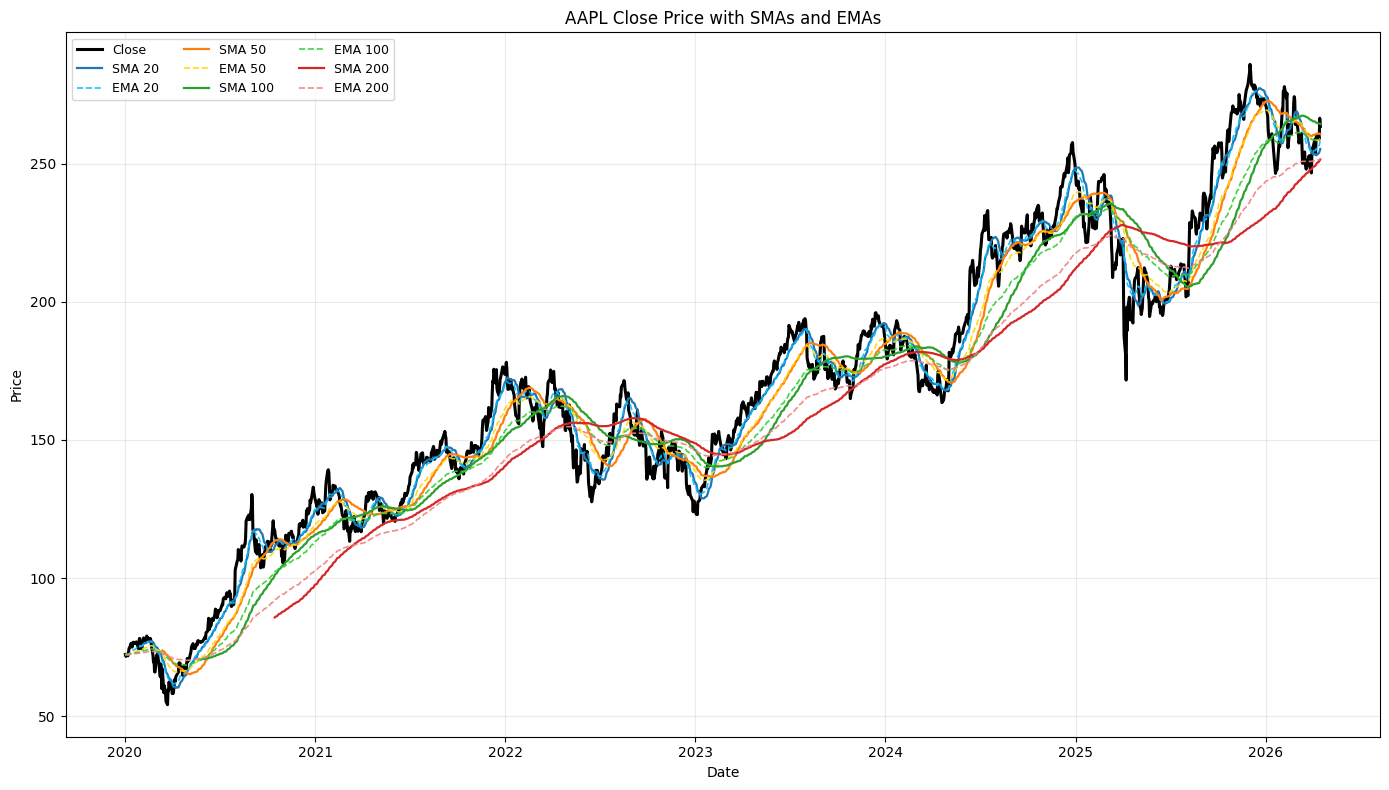

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14, 8))
ax.plot(df.index, df["close"], color="black", linewidth=2.2, label="Close")

sma_colors = {20: "tab:blue", 50: "tab:orange", 100: "tab:green", 200: "tab:red"}
ema_colors = {20: "deepskyblue", 50: "gold", 100: "limegreen", 200: "lightcoral"}

for window in windows:
    ax.plot(df.index, df[f"sma_{window}"], linewidth=1.6, color=sma_colors[window], label=f"SMA {window}")
    ax.plot(
        df.index,
        df[f"ema_{window}"],
        linewidth=1.2,
        linestyle="--",
        color=ema_colors[window],
        alpha=0.9,
        label=f"EMA {window}",
    )

ax.set_title(f"{TICKER} Close Price with SMAs and EMAs")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.grid(alpha=0.25)
ax.legend(ncol=3, fontsize=9)
fig.tight_layout()
plt.show()

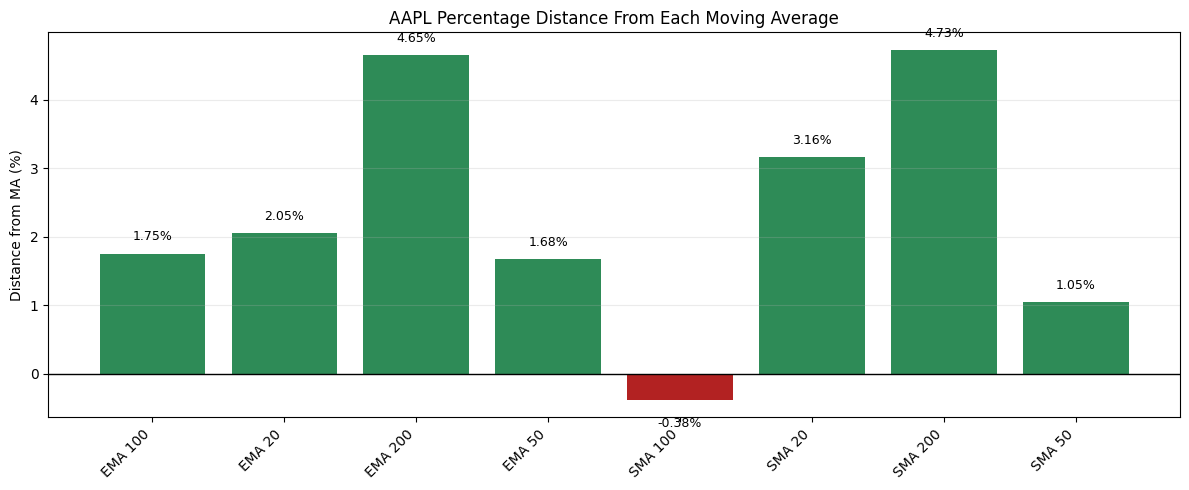

In [7]:
distance_series = pd.Series(
    {
        f"SMA {window}": (latest["close"] / latest[f"sma_{window}"] - 1) * 100
        for window in windows
    }
    | {
        f"EMA {window}": (latest["close"] / latest[f"ema_{window}"] - 1) * 100
        for window in windows
    }
).sort_index()

colors = ["seagreen" if value >= 0 else "firebrick" for value in distance_series]
positions = range(len(distance_series))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(positions, distance_series.values, color=colors)
ax.axhline(0, color="black", linewidth=1)
ax.set_title(f"{TICKER} Percentage Distance From Each Moving Average")
ax.set_ylabel("Distance from MA (%)")
ax.set_xticks(list(positions), distance_series.index, rotation=45, ha="right")
ax.grid(axis="y", alpha=0.25)

for bar, value in zip(bars, distance_series.values):
    offset = 0.15 if value >= 0 else -0.25
    va = "bottom" if value >= 0 else "top"
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + offset,
        f"{value:.2f}%",
        ha="center",
        va=va,
        fontsize=9,
    )

fig.tight_layout()
plt.show()